In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
%cd /content/Zepto-Capstone-Project

!git fetch origin
!git checkout feature/module-2
!git pull

/content/Zepto-Capstone-Project
Already on 'feature/module-2'
Your branch is up to date with 'origin/feature/module-2'.
Already up to date.


In [12]:
%cd /content/Zepto-Capstone-Project

!git branch --show-current

/content/Zepto-Capstone-Project
feature/module-2


In [13]:
!git fetch origin
!git checkout feature/module-2
!git pull origin feature/module-2

Already on 'feature/module-2'
Your branch is up to date with 'origin/feature/module-2'.
From https://github.com/Maheshbaki/Zepto-Capstone-Project
 * branch            feature/module-2 -> FETCH_HEAD
Already up to date.


In [16]:
import pandas as pd

path = "/content/Zepto-Capstone-Project/analytics/titanic_cleaned.csv"

df = pd.read_csv(path)

print("Modeling dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())

Modeling dataset shape: (889, 15)
Columns:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'age_group']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Young Adult


In [23]:
# Define the target variable
y = df["survived"]

# Remove columns that should not be used as model features
X = df.drop(
    columns=[
        "survived",   # target
        "alive",      # directly reveals survival - target leakage
        "class"       # duplicate of pclass
    ]
)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features shape: (889, 12)
Target shape: (889,)

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'adult_male', 'embark_town', 'alone', 'age_group']


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (711, 12)
Testing features: (178, 12)
Training target: (711,)
Testing target: (178,)


In [25]:
print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Original target distribution:
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Training target distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked', 'who', 'adult_male', 'embark_town', 'alone', 'age_group']


In [27]:
# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [28]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked', 'who', 'adult_male', 'embark_town', 'alone', 'age_group']


##Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported.")

Logistic Regression imported.


In [30]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [31]:
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [32]:
y_pred_logistic = logistic_pipeline.predict(X_test)

print("Predictions generated.")
print("First 10 predictions:")
print(y_pred_logistic[:10])

Predictions generated.
First 10 predictions:
[0 0 0 0 0 1 0 1 1 0]


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

Logistic Regression Results
---------------------------
Accuracy : 0.8258
Precision: 0.8136
Recall   : 0.7059
F1 Score : 0.7559


Confusion Matrix:
[[99 11]
 [20 48]]


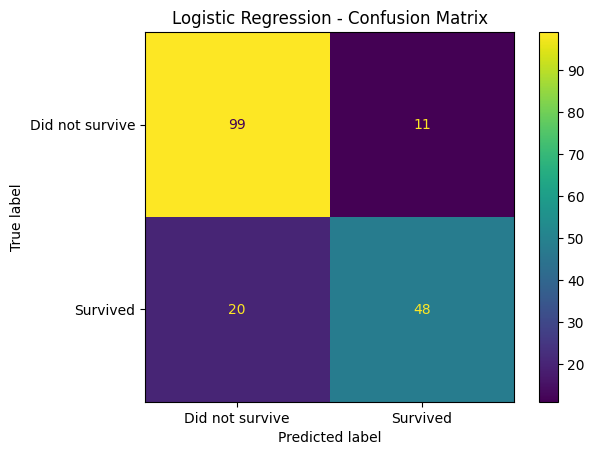

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print("Confusion Matrix:")
print(cm_logistic)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Did not survive", "Survived"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Logistic Regression ROC-AUC: 0.8647


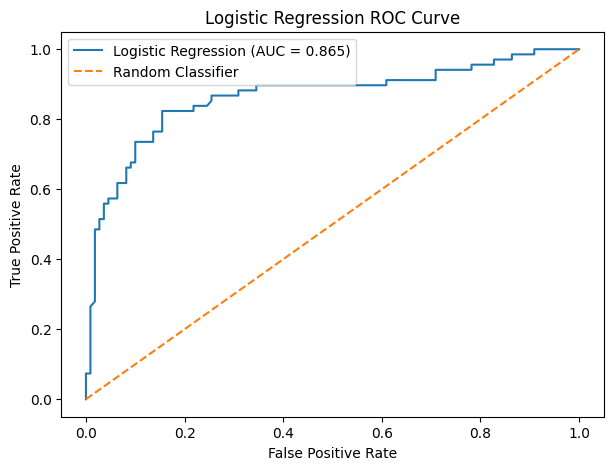

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

logistic_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(
    y_test,
    y_prob_logistic
)

print("Logistic Regression ROC-AUC:", round(logistic_auc, 4))

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

### Logistic Regression Thoughts

The Logistic Regression baseline achieved an accuracy of 82.58% and a ROC-AUC of 0.8647 on the test set. Precision was 81.36%, while recall was 70.59%, resulting in an F1 score of 75.59%.

The confusion matrix shows that the model correctly classified 99 non-survivors and 48 survivors. It incorrectly classified 11 non-survivors as survivors and 20 survivors as non-survivors.

Overall, the baseline model provides a reasonably strong starting point for the Titanic survival prediction task, but the lower recall indicates that some actual survivors are still being missed.

##Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier

print("Decision Tree imported successfully.")

Decision Tree imported successfully.


In [38]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

print("Decision Tree pipeline created.")

Decision Tree pipeline created.


In [39]:
decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [40]:
y_pred_tree = decision_tree_pipeline.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))

Decision Tree Results
--------------------
Accuracy : 0.7921
Precision: 0.8163
Recall   : 0.5882
F1 Score : 0.6838


Confusion Matrix:
[[101   9]
 [ 28  40]]


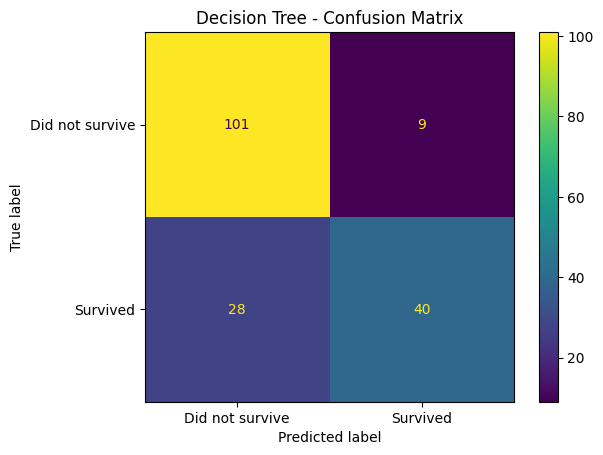

In [41]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Confusion Matrix:")
print(cm_tree)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Did not survive", "Survived"]
).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

Decision Tree ROC-AUC: 0.8285


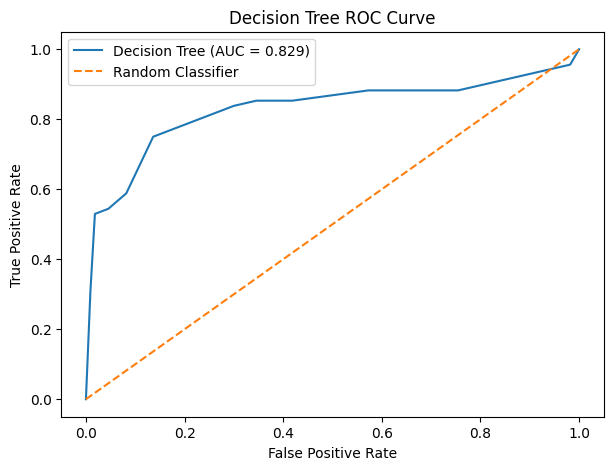

In [42]:
y_prob_tree = decision_tree_pipeline.predict_proba(X_test)[:, 1]

tree_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

print("Decision Tree ROC-AUC:", round(tree_auc, 4))

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

### Decision Tree Thoughts

The Decision Tree achieved an accuracy of 79.21% and a ROC-AUC of 0.8285. Its precision was 81.63%, recall was 58.82%, and F1 score was 68.38%.

Compared with the Logistic Regression baseline, the Decision Tree performed worse on accuracy, recall, F1 score, and ROC-AUC, although its precision was slightly higher. The lower recall indicates that the Decision Tree missed more actual survivors than the Logistic Regression model.

The confusion matrix shows that the Decision Tree correctly classified 101 non-survivors and 40 survivors, while incorrectly classifying 9 non-survivors and 28 survivors.

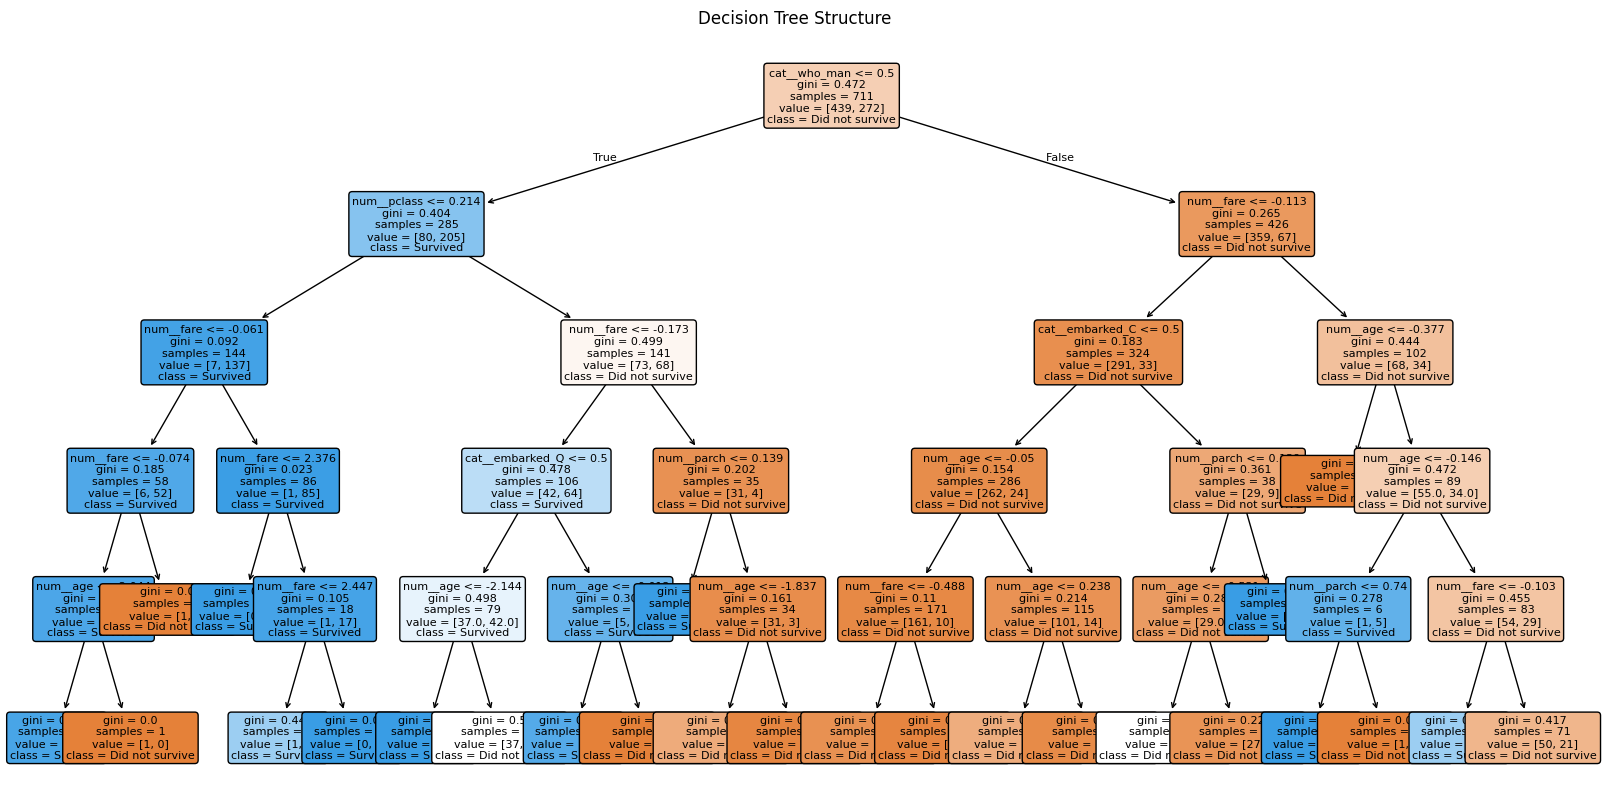

In [43]:
from sklearn.tree import plot_tree

# Get the trained preprocessing transformer
fitted_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]

# Get the trained decision tree
trained_tree = decision_tree_pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    trained_tree,
    feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Structure")
plt.show()

##Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully.")

Random Forest imported successfully.


In [45]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [46]:
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [47]:
y_pred_rf = random_forest_pipeline.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Results
--------------------
Accuracy : 0.7978
Precision: 0.7581
Recall   : 0.6912
F1 Score : 0.7231


Confusion Matrix:
[[95 15]
 [21 47]]


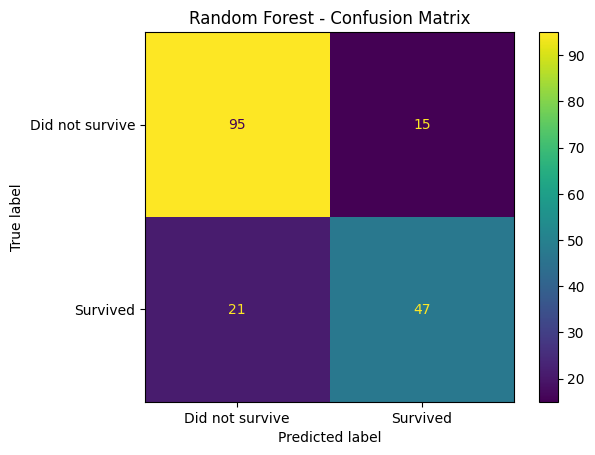

In [48]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Did not survive", "Survived"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

Random Forest ROC-AUC: 0.8235


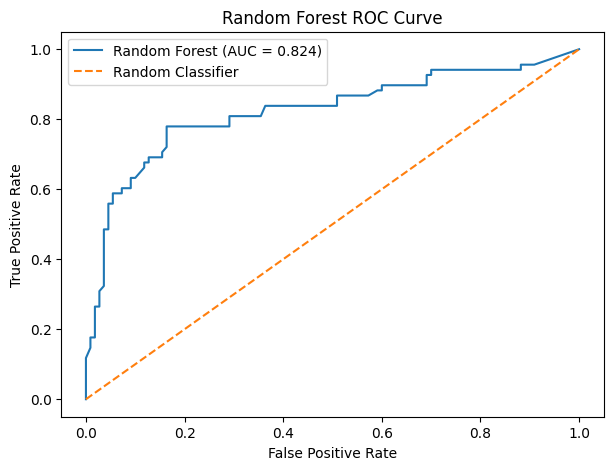

In [49]:
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

print("Random Forest ROC-AUC:", round(rf_auc, 4))

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

### Random Forest Thoughts

The Random Forest achieved an accuracy of 79.78%, precision of 75.81%, recall of 69.12%, F1 score of 72.31%, and ROC-AUC of 0.8235.

Compared with the Logistic Regression baseline, the Random Forest performed worse on accuracy, precision, F1 score, and ROC-AUC, while its recall was slightly lower. The confusion matrix shows that it correctly classified 95 non-survivors and 47 survivors, while incorrectly classifying 15 non-survivors and 21 survivors.

Although Random Forest is a more flexible ensemble model, its initial untuned performance is not better than the Logistic Regression baseline on this dataset. We will later tune the Random Forest using GridSearchCV as required by the project.

##Model Comparison

In [50]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        tree_auc,
        rf_auc
    ]
})

display(
    model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8258,0.8136,0.7059,0.7559,0.8647
1,Decision Tree,0.7921,0.8163,0.5882,0.6838,0.8285
2,Random Forest,0.7978,0.7581,0.6912,0.7231,0.8235


##One Combined ROC plot

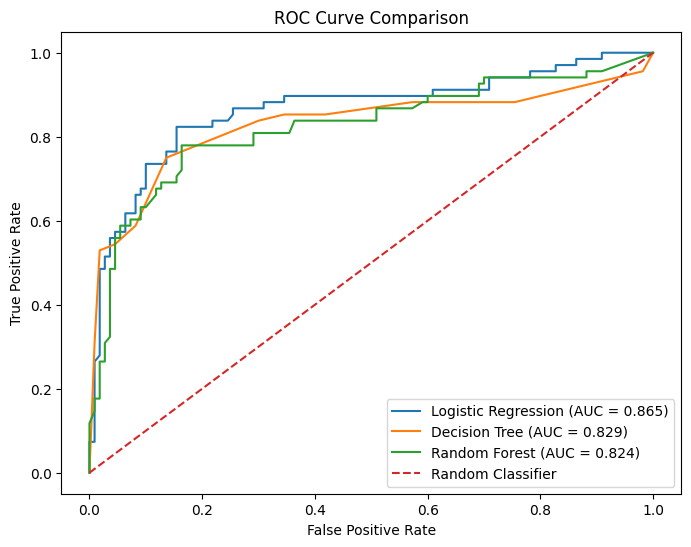

In [51]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

## Tackling Class imbalance

In [52]:
print("Class distribution:")
print(y_train.value_counts())

print("\nClass proportions:")
print(y_train.value_counts(normalize=True))

Class distribution:
survived
0    439
1    272
Name: count, dtype: int64

Class proportions:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64


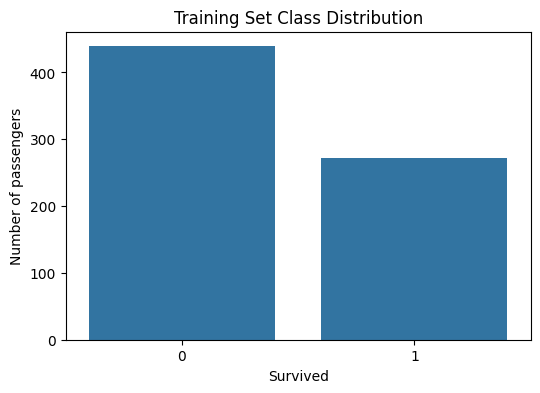

In [54]:
import seaborn as sns
plt.figure(figsize=(6, 4))

sns.countplot(
    x=y_train
)

plt.xlabel("Survived")
plt.ylabel("Number of passengers")
plt.title("Training Set Class Distribution")

plt.show()

### Class Imbalance — Interpretation

The target variable is moderately imbalanced. Approximately 61.6% of passengers did not survive, while 38.4% survived. The majority class therefore contains more observations than the minority class. Because recall for the minority class is important, SMOTE will be evaluated as a possible way to improve minority-class representation during training.

In [55]:
!pip install -q imbalanced-learn

In [63]:
# SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [64]:
smote_rf_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("SMOTE Random Forest pipeline created.")

SMOTE Random Forest pipeline created.


In [65]:
smote_rf_pipeline.fit(
    X_train,
    y_train
)

print("SMOTE Random Forest trained successfully.")

SMOTE Random Forest trained successfully.


In [66]:
y_pred_smote = smote_rf_pipeline.predict(X_test)

smote_accuracy = accuracy_score(
    y_test,
    y_pred_smote
)

smote_precision = precision_score(
    y_test,
    y_pred_smote
)

smote_recall = recall_score(
    y_test,
    y_pred_smote
)

smote_f1 = f1_score(
    y_test,
    y_pred_smote
)

y_prob_smote = smote_rf_pipeline.predict_proba(
    X_test
)[:, 1]

smote_auc = roc_auc_score(
    y_test,
    y_prob_smote
)

print("Random Forest + SMOTE Results")
print("-----------------------------")
print("Accuracy :", round(smote_accuracy, 4))
print("Precision:", round(smote_precision, 4))
print("Recall   :", round(smote_recall, 4))
print("F1 Score :", round(smote_f1, 4))
print("ROC-AUC  :", round(smote_auc, 4))

Random Forest + SMOTE Results
-----------------------------
Accuracy : 0.8034
Precision: 0.7463
Recall   : 0.7353
F1 Score : 0.7407
ROC-AUC  : 0.8314


Confusion Matrix:
[[93 17]
 [18 50]]


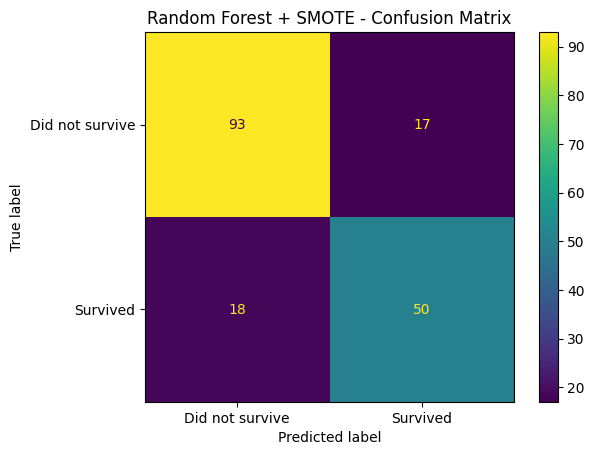

In [67]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)

print("Confusion Matrix:")
print(cm_smote)

ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=["Did not survive", "Survived"]
).plot()

plt.title("Random Forest + SMOTE - Confusion Matrix")
plt.show()

### SMOTE — Interpretation

The original Random Forest achieved an accuracy of 79.78%, recall of 69.12%, F1 score of 72.31%, and ROC-AUC of 0.8235.

After applying SMOTE only to the training data, accuracy increased to 80.34%, recall increased to 73.53%, F1 increased to 74.07%, and ROC-AUC increased to 0.8314. Precision decreased slightly from 75.81% to 74.63%.

The improvement in recall indicates that the SMOTE model identified more actual survivors. The increase in F1 and ROC-AUC also suggests an overall improvement in classification performance. However, the precision trade-off should be considered when selecting the final model.

##GridSearchCV

In [68]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully.")

GridSearchCV imported successfully.


In [69]:
rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest tuning pipeline created.")

Random Forest tuning pipeline created.


In [70]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

print("Parameter grid:")
print(param_grid)

Parameter grid:
{'model__n_estimators': [100, 200], 'model__max_depth': [None, 5, 10], 'model__min_samples_split': [2, 5], 'model__min_samples_leaf': [1, 2]}


In [71]:
grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

GridSearchCV completed.


In [72]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1 score:")
print(round(grid_search.best_score_, 4))

Best parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best cross-validation F1 score:
0.7654


In [73]:
best_rf_pipeline = grid_search.best_estimator_

y_pred_best_rf = best_rf_pipeline.predict(X_test)

best_rf_accuracy = accuracy_score(y_test, y_pred_best_rf)
best_rf_precision = precision_score(y_test, y_pred_best_rf)
best_rf_recall = recall_score(y_test, y_pred_best_rf)
best_rf_f1 = f1_score(y_test, y_pred_best_rf)

y_prob_best_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

best_rf_auc = roc_auc_score(
    y_test,
    y_prob_best_rf
)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", round(best_rf_accuracy, 4))
print("Precision:", round(best_rf_precision, 4))
print("Recall   :", round(best_rf_recall, 4))
print("F1 Score :", round(best_rf_f1, 4))
print("ROC-AUC  :", round(best_rf_auc, 4))

Tuned Random Forest Results
---------------------------
Accuracy : 0.8202
Precision: 0.8103
Recall   : 0.6912
F1 Score : 0.746
ROC-AUC  : 0.8402


### GridSearchCV Thoughts

GridSearchCV selected a Random Forest with 200 trees, a maximum depth of 5, minimum samples per leaf of 1, and minimum samples required to split of 2. The best cross-validation F1 score was 0.7654.

On the untouched test set, the tuned Random Forest achieved 82.02% accuracy, 81.03% precision, 69.12% recall, 74.60% F1 score, and 0.8402 ROC-AUC.

The tuned Random Forest improved over the initial Random Forest model, particularly in accuracy, precision, F1 score, and ROC-AUC. However, Logistic Regression still achieved a higher test ROC-AUC and F1 score in this experiment.

##Random Forest OOB Score

In [74]:
oob_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=1,
            min_samples_split=2,
            random_state=42,
            n_jobs=-1,
            oob_score=True
        ))
    ]
)

print("OOB Random Forest pipeline created.")

OOB Random Forest pipeline created.


In [75]:
oob_rf_pipeline.fit(X_train, y_train)

print("OOB Random Forest trained successfully.")

OOB Random Forest trained successfully.


In [76]:
oob_score = oob_rf_pipeline.named_steps["model"].oob_score_

print("Random Forest OOB Score:", round(oob_score, 4))

Random Forest OOB Score: 0.8256


### Random Forest OOB Score Thoughts

The tuned Random Forest achieved an out-of-bag (OOB) score of 0.8256. This means that the model correctly classified approximately 82.56% of the out-of-bag training observations. The OOB estimate provides an internal measure of model performance using observations that were not included in the bootstrap sample for each individual tree.

##LinearRegression on Fare

In [77]:
# Target for regression
y_fare = df["fare"]

# Remove fare itself and survival-related target/leakage columns
X_fare = df.drop(
    columns=["fare", "survived", "alive"]
)

print("Regression features:")
print(X_fare.columns.tolist())

print("\nRegression target:")
print("fare")

Regression features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone', 'age_group']

Regression target:
fare


In [78]:
X_fare_train, X_fare_test, y_fare_train, y_fare_test = train_test_split(
    X_fare,
    y_fare,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_fare_train.shape)
print("Testing features:", X_fare_test.shape)

Training features: (711, 12)
Testing features: (178, 12)


In [79]:
fare_numeric_features = X_fare_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

fare_categorical_features = X_fare_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(fare_numeric_features)

print("\nCategorical features:")
print(fare_categorical_features)

Numerical features:
['pclass', 'age', 'sibsp', 'parch']

Categorical features:
['sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone', 'age_group']


In [80]:
fare_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

fare_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

fare_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            fare_numeric_transformer,
            fare_numeric_features
        ),
        (
            "cat",
            fare_categorical_transformer,
            fare_categorical_features
        )
    ]
)

print("Fare regression preprocessor created.")

Fare regression preprocessor created.


In [81]:
from sklearn.linear_model import LinearRegression

fare_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", fare_preprocessor),
        ("model", LinearRegression())
    ]
)

print("Fare regression pipeline created.")

Fare regression pipeline created.


In [82]:
fare_regression_pipeline.fit(
    X_fare_train,
    y_fare_train
)

print("Fare regression model trained successfully.")

Fare regression model trained successfully.


In [83]:
y_fare_pred = fare_regression_pipeline.predict(
    X_fare_test
)

print("Fare predictions generated.")
print("First 10 predictions:")
print(y_fare_pred[:10])

Fare predictions generated.
First 10 predictions:
[  1.42255244  95.78010267  16.91126126   9.35498701 109.85414336
   2.093707    12.71075981   6.12063436 111.27532493  90.89105517]


In [84]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(
    y_fare_test,
    y_fare_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_fare_test,
        y_fare_pred
    )
)

r2 = r2_score(
    y_fare_test,
    y_fare_pred
)

print("Fare Regression Results")
print("-----------------------")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Fare Regression Results
-----------------------
MAE : 18.553
RMSE: 41.5188
R²  : 0.3539


In [85]:
n = len(y_fare_test)

X_fare_test_transformed = fare_regression_pipeline.named_steps[
    "preprocessor"
].transform(X_fare_test)

p = X_fare_test_transformed.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("Number of test observations:", n)
print("Number of transformed predictors:", p)
print("Adjusted R²:", round(adjusted_r2, 4))

Number of test observations: 178
Number of transformed predictors: 27
Adjusted R²: 0.2376


### Fare LinearRegression Thoughts

The Linear Regression model achieved a Mean Absolute Error (MAE) of 18.5530, Root Mean Squared Error (RMSE) of 41.5188, R² of 0.3539, and adjusted R² of 0.2376.

The R² indicates that the model explains approximately 35.4% of the variation in passenger fare on the test set. The lower adjusted R² of 23.76% reflects the effect of using 27 transformed predictors after categorical encoding.

The RMSE is substantially higher than the MAE, indicating that some observations have relatively large prediction errors. Overall, the regression model has limited explanatory power, suggesting that passenger fare is influenced by factors not fully captured by the available features.

In [86]:
# Calculate residuals
residuals = y_fare_test - y_fare_pred

print("Residual mean:", round(residuals.mean(), 4))
print("Residual standard deviation:", round(residuals.std(), 4))

Residual mean: -0.7674
Residual standard deviation: 41.6288


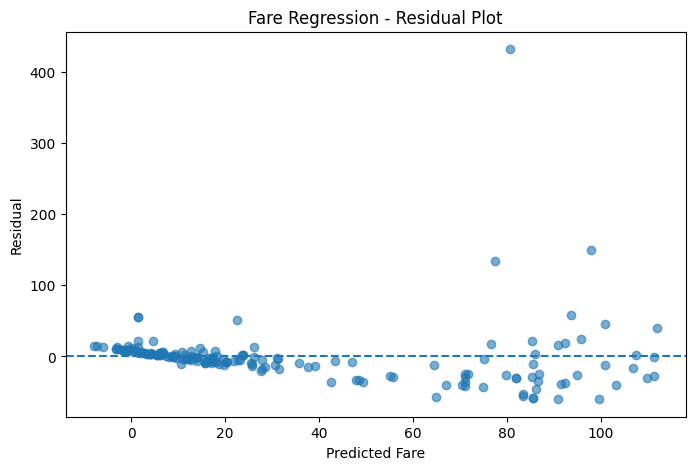

In [87]:
# Residual plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    y_fare_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Fare Regression - Residual Plot")

plt.show()

### Residual Analysis and Heteroscedasticity

The residual plot shows that the residuals are not evenly distributed around zero across all predicted fare values. At lower predicted fares, the residuals are relatively concentrated, while at higher predicted fares their spread becomes substantially larger.

This widening pattern suggests the presence of heteroscedasticity, meaning that the variance of the regression errors is not constant. The plot also contains several large residuals, indicating that some observations are difficult for the Linear Regression model to predict accurately.

Therefore, the constant-variance assumption of ordinary linear regression appears to be violated for this fare prediction task.

##Final comparison table

In [90]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Random Forest + SMOTE",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        smote_accuracy,
        best_rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision,
        smote_precision,
        best_rf_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall,
        smote_recall,
        best_rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1,
        smote_f1,
        best_rf_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        tree_auc,
        rf_auc,
        smote_auc,
        best_rf_auc
    ]
})

display(
    final_model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8258,0.8136,0.7059,0.7559,0.8647
1,Decision Tree,0.7921,0.8163,0.5882,0.6838,0.8285
2,Random Forest,0.7978,0.7581,0.6912,0.7231,0.8235
3,Random Forest + SMOTE,0.8034,0.7463,0.7353,0.7407,0.8314
4,Tuned Random Forest,0.8202,0.8103,0.6912,0.7460,0.8402


## Final Classification Model Selection

Logistic Regression was selected as the final classification model based on the test-set results. It achieved the highest accuracy (82.58%), F1 score (75.59%), and ROC-AUC (0.8647) among the evaluated models.

The Random Forest with SMOTE achieved the highest recall at 73.53%, which means it identified more actual survivors. However, its precision, F1 score, accuracy, and ROC-AUC were lower than those of Logistic Regression.

The tuned Random Forest improved substantially over the initial Random Forest, achieving 82.02% accuracy and 0.8402 ROC-AUC, but it still did not outperform Logistic Regression overall.

Therefore, Logistic Regression provides the strongest overall balance of predictive performance for this dataset and is selected as the final classification model.

In [91]:
import joblib

model_path = "/content/Zepto-Capstone-Project/analytics/final_logistic_model.joblib"

joblib.dump(
    logistic_pipeline,
    model_path
)

print("Final model saved successfully.")
print("Path:", model_path)

Final model saved successfully.
Path: /content/Zepto-Capstone-Project/analytics/final_logistic_model.joblib


In [92]:
loaded_model = joblib.load(model_path)

print("Model reloaded successfully.")

Model reloaded successfully.


In [93]:
loaded_predictions = loaded_model.predict(X_test)

print(
    "Predictions from reloaded model:",
    loaded_predictions[:10]
)

print(
    "Reloaded model accuracy:",
    round(
        accuracy_score(y_test, loaded_predictions),
        4
    )
)

Predictions from reloaded model: [0 0 0 0 0 1 0 1 1 0]
Reloaded model accuracy: 0.8258


# Module 2 — Final Summary

## Classification

Five classification approaches were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Random Forest with SMOTE
5. Tuned Random Forest using GridSearchCV

Logistic Regression was selected as the final classification model because it achieved the highest overall test performance, including 82.58% accuracy, 75.59% F1 score, and 0.8647 ROC-AUC.

Random Forest with SMOTE achieved the highest recall (73.53%), showing improved detection of survivors, but its overall F1 and ROC-AUC were lower than Logistic Regression.

## Regression

A Linear Regression model was used to predict passenger fare.

Results:

- MAE: 18.5530
- RMSE: 41.5188
- R²: 0.3539
- Adjusted R²: 0.2376

The residual plot showed increasing residual spread at higher predicted fare values, suggesting heteroscedasticity and indicating that the linear regression model does not have constant error variance.

## Model Persistence

The final Logistic Regression pipeline, including preprocessing, was saved using `joblib` and successfully reloaded. The reloaded model achieved the same test accuracy of 82.58%, confirming that the saved model can be restored and used for prediction.